In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import mne

# Correct data root for the mounted server location
DATA_ROOT = Path("/srv/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD")
REPO_ROOT = DATA_ROOT / "LEAD_ExperimentalFolder"

os.chdir(DATA_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.environ["PYTHONPATH"] = str(REPO_ROOT) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead

# Important variables
cwd = DATA_ROOT
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

# Publication-quality plotting defaults
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.05

/tmp/ipykernel_293500/1315059578.py:35: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  .decimate(5)


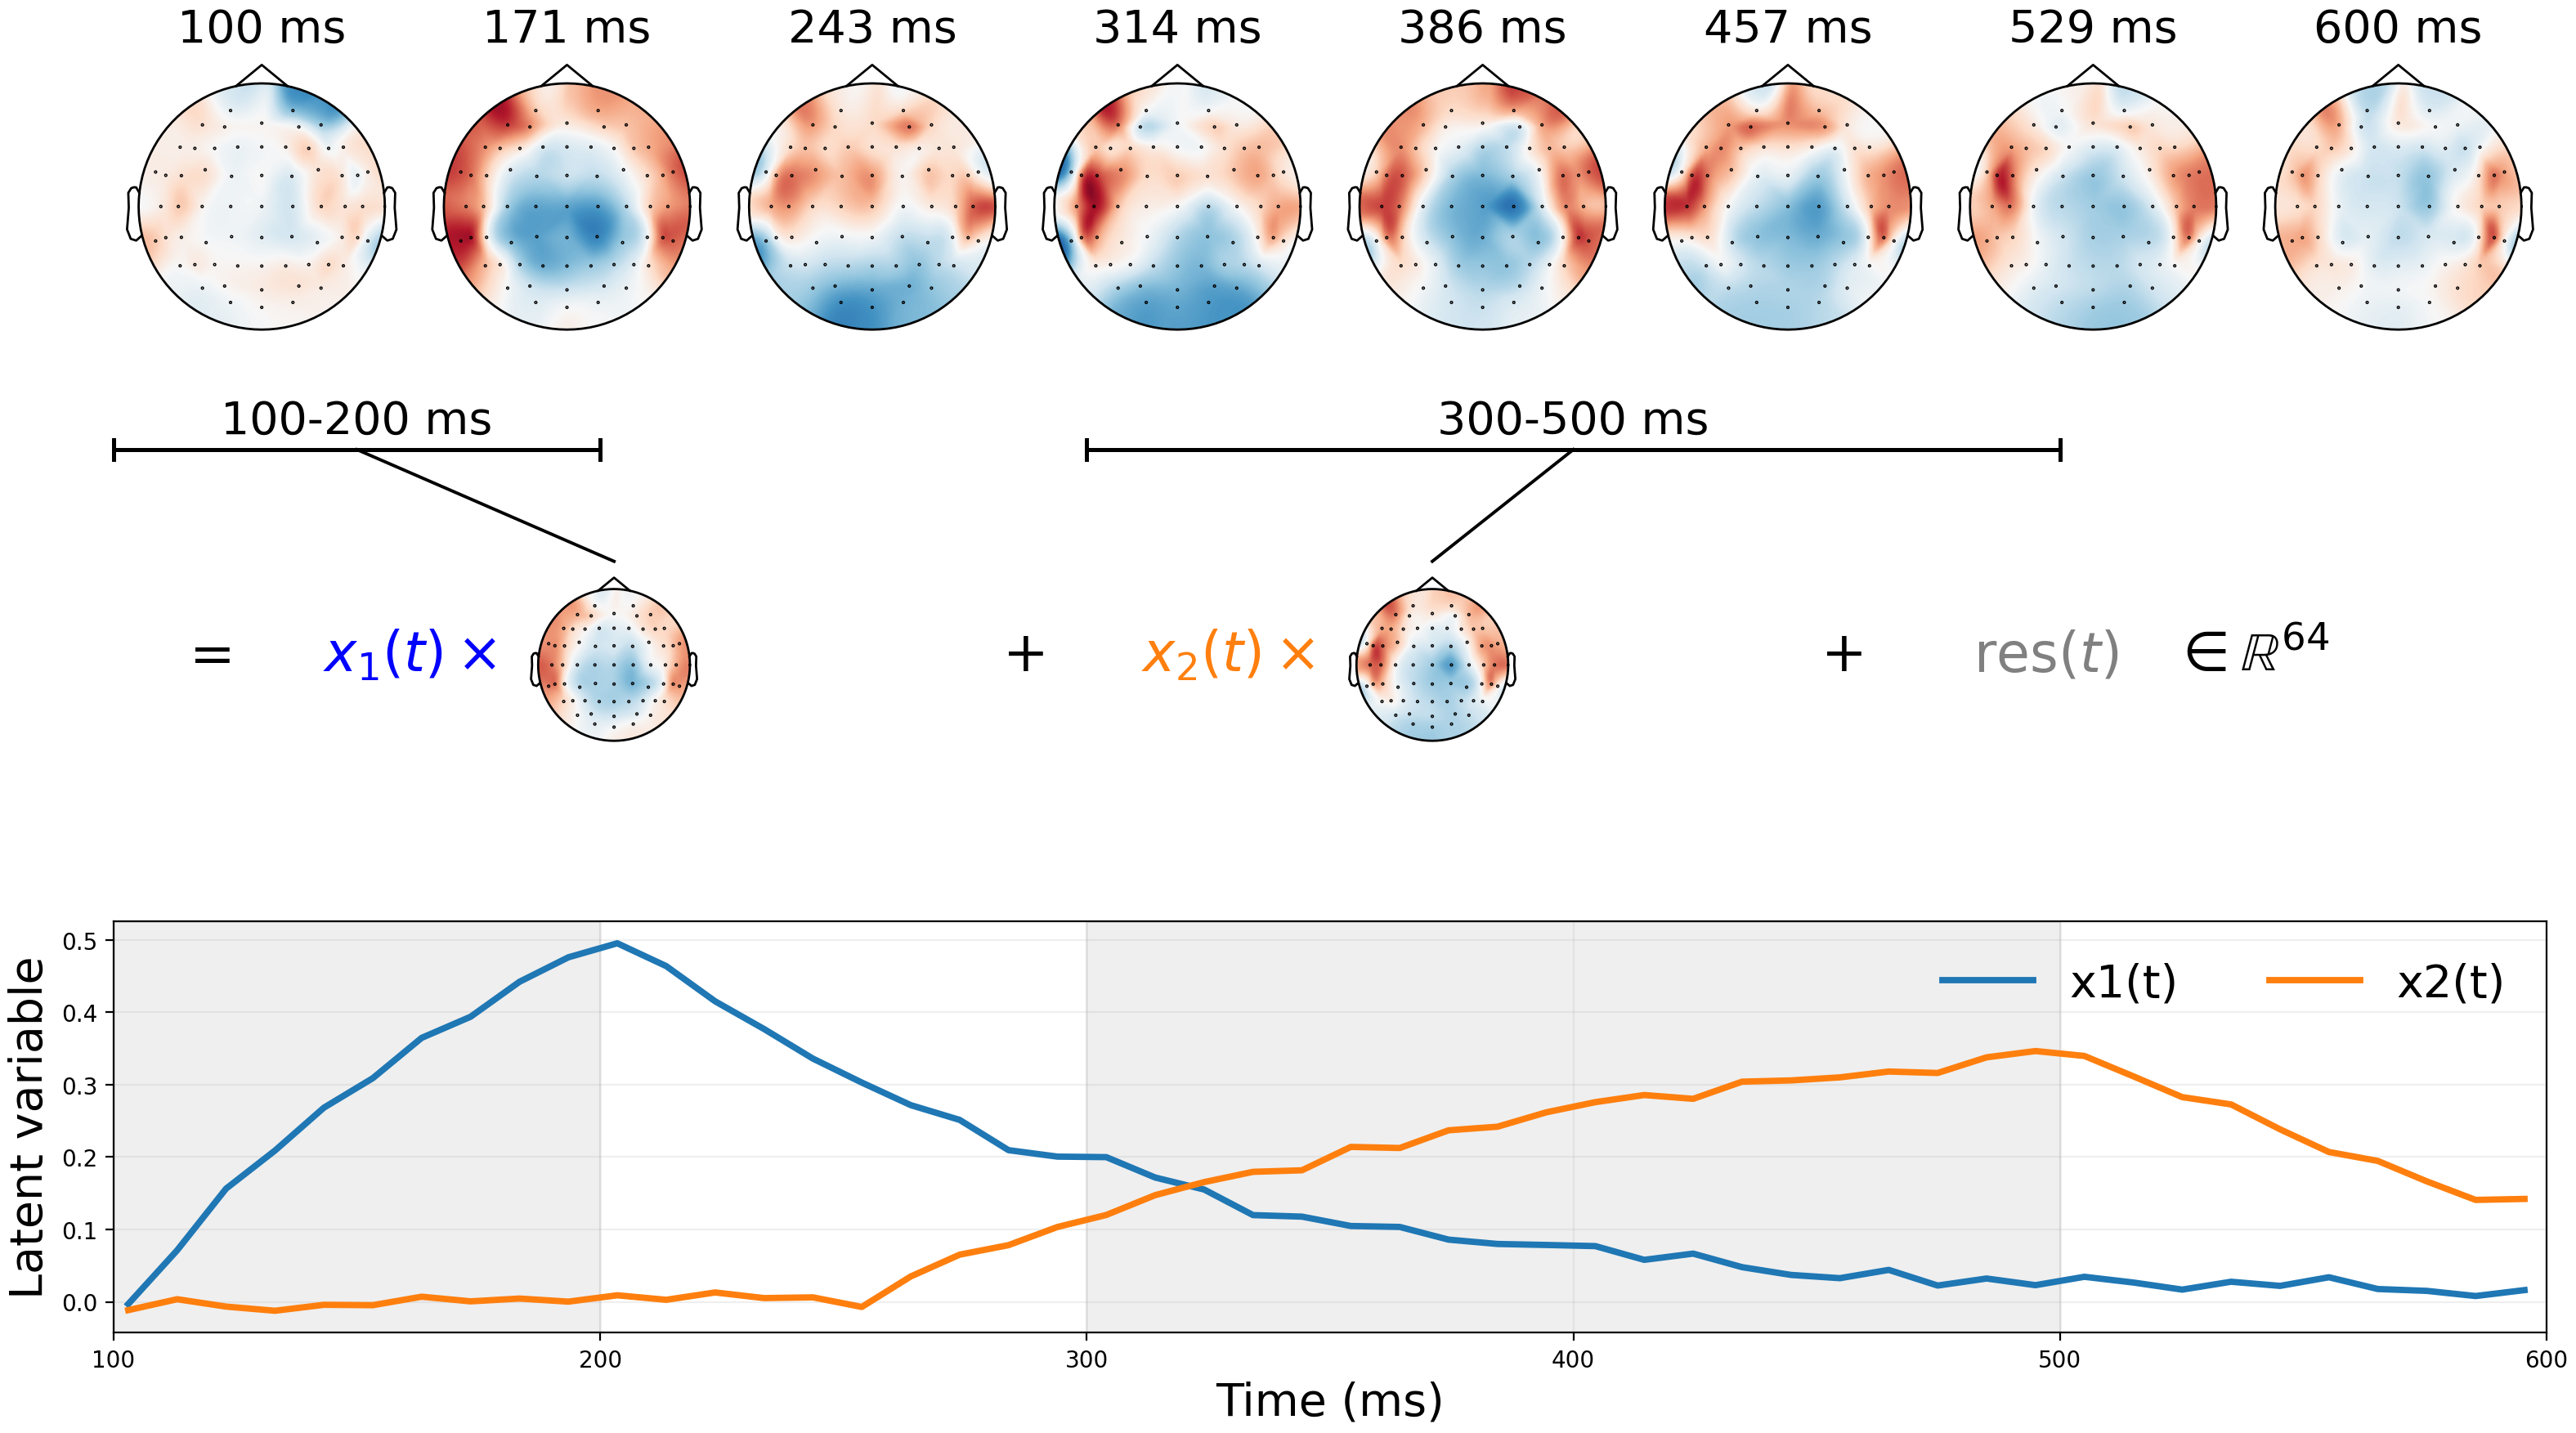

In [10]:
import numpy as np
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import mne

# ------------------------------------------------------------------
# Self-contained figure cell: topographies + averaged maps + trajectories
# ------------------------------------------------------------------
np.random.seed(42)

# Paths and imports
DATA_ROOT = Path("/srv/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD")
REPO_ROOT = DATA_ROOT / "LEAD_ExperimentalFolder"

os.chdir(DATA_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.environ["PYTHONPATH"] = str(REPO_ROOT) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead

# Parameters (same conventions as previous cells)
task = "Passive"
part = 4
SubIDs = ["01", "02", "03", "05", "06", "07", "08", "09", "11", "12", "13", "14", "15", "17", "19", "20", "22", "23", "24", "25"]

tmin, tmax = 0.1, 0.6
epochs_file = DATA_ROOT / f"myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif"

epochs = (
    mne.read_epochs(epochs_file, preload=True, verbose=False)
    .decimate(5)
    .crop(tmin=tmin, tmax=tmax, include_tmax=True, verbose=False)
)

max_cat = int(np.max(np.unique(epochs.metadata["snr"])))
stim_pres_epochs = epochs[str(max_cat)]
evoked = stim_pres_epochs.average()

topo_times = np.linspace(tmin, tmax, 8)

avg_010_020 = evoked.copy().crop(tmin=0.1, tmax=0.2, include_tmax=True).data.mean(axis=1)
avg_030_050 = evoked.copy().crop(tmin=0.3, tmax=0.5, include_tmax=True).data.mean(axis=1)

file_path_late = f"Fit_{task}_late"
gainmodul_late = lead.model.StratifiedGainModulation(
    tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5
)
gainmodul_late.load_params(f"LEAD_ExperimentalFolder/{file_path_late}/GainModulatedModel_part{part}_params")

one_input_late = np.concatenate((np.zeros(75), np.ones(25), np.zeros(100)))
input_train_late = {5: np.stack([one_input_late for _ in range(10000)])}
simulations_gainmodul_late = gainmodul_late.measure_simulations(input_series=input_train_late)

file_path_early = f"Fit_{task}_early"
gainmodul_early = lead.model.StratifiedGainModulation(
    tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5
)
gainmodul_early.load_params(f"LEAD_ExperimentalFolder/{file_path_early}/GainModulatedModel_part{part}_params")

one_input_early = np.concatenate((np.zeros(60), np.ones(10), np.zeros(130)))
input_train_early = {5: np.stack([one_input_early for _ in range(10000)])}
simulations_gainmodul_early = gainmodul_early.measure_simulations(input_series=input_train_early)

plt.rcParams["figure.dpi"] = 200
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.pad_inches"] = 0.05

fig = plt.figure(figsize=(16, 10))
outer = fig.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=[1.35, 1.05, 1.4],
    hspace=0.30,
    left=0.05,
    right=0.98,
    bottom=0.08,
    top=0.90,
)

gs_top = outer[0].subgridspec(1, 8, wspace=0.03)
axes_top = [fig.add_subplot(gs_top[0, i]) for i in range(8)]

vlim = (np.min(evoked.data), np.max(evoked.data))
for i, t in enumerate(topo_times):
    data_t = evoked.copy().crop(tmin=t, tmax=t, include_tmax=True).data[:, 0]
    mne.viz.plot_topomap(
        data_t,
        evoked.info,
        axes=axes_top[i],
        show=False,
        vlim=vlim,
        contours=0,
        cmap="RdBu_r",
    )
    axes_top[i].set_title(f"{int(round(t * 1000))} ms", fontsize=20, pad=2)

# Row 2: averaged topographies
gs_mid = outer[1].subgridspec(1, 12, wspace=0.12)
ax_mid0 = fig.add_subplot(gs_mid[0, 0])
ax_mid1_lab = fig.add_subplot(gs_mid[0, 1])
ax_mid1 = fig.add_subplot(gs_mid[0, 2])
ax_mid1_plus = fig.add_subplot(gs_mid[0, 4])
ax_mid2_lab = fig.add_subplot(gs_mid[0, 5])
ax_mid3 = fig.add_subplot(gs_mid[0, 6])
ax_mid2_plus = fig.add_subplot(gs_mid[0, 8])
ax_mid4_lab = fig.add_subplot(gs_mid[0, 9])
ax_mid5 = fig.add_subplot(gs_mid[0, 10])

for ax in [ax_mid0, ax_mid1_lab, ax_mid1_plus, ax_mid2_lab, ax_mid2_plus, ax_mid4_lab, ax_mid5]:
    ax.set_axis_off()

ax_mid0.text(0.5, 0.5, r"$=$", color="black", fontsize=24, ha="center", va="center")
ax_mid1_lab.text(0.5, 0.5, r"$x_1(t) \times$", color="blue", fontsize=24, ha="center", va="center")
ax_mid1_plus.text(0.5, 0.5, r"$+$", color="black", fontsize=24, ha="center", va="center")
ax_mid2_lab.text(0.5, 0.5, r"$x_2(t) \times$", color="tab:orange", fontsize=24, ha="center", va="center")
ax_mid2_plus.text(0.5, 0.5, r"$+$", color="black", fontsize=24, ha="center", va="center")
ax_mid4_lab.text(0.5, 0.5, r"$\mathrm{res}(t)$", color="gray", fontsize=24, ha="center", va="center")
ax_mid5.text(0.5, 0.5, r"$\in \mathbb{R}^{64}$", color="black", fontsize=24, ha="center", va="center")

mne.viz.plot_topomap(
    avg_010_020,
    evoked.info,
    axes=ax_mid1,
    show=False,
    vlim=vlim,
    contours=0,
    cmap="RdBu_r",
)

mne.viz.plot_topomap(
    avg_030_050,
    evoked.info,
    axes=ax_mid3,
    show=False,
    vlim=vlim,
    contours=0,
    cmap="RdBu_r",
)

# Row 3: trajectories (20 individual + mean)
ax_traj = fig.add_subplot(outer[2, 0])
times_ms = np.linspace(-500, 1500, 200)
mask = (times_ms >= 100) & (times_ms <= 600)
t_segment = times_ms[mask]

early_data = simulations_gainmodul_early[5][:, mask]
late_data = simulations_gainmodul_late[5][:, mask]

rng = np.random.default_rng(42)
sel_early = rng.choice(early_data.shape[0], size=20, replace=False)
sel_late = rng.choice(late_data.shape[0], size=20, replace=False)

# for i in sel_early:
#     ax_traj.plot(t_segment, early_data[i], color="tab:blue", alpha=0.14, linewidth=1.0)
# for i in sel_late:
#     ax_traj.plot(t_segment, late_data[i], color="tab:orange", alpha=0.14, linewidth=1.0)

mean_early = np.mean(early_data, axis=0)
mean_late = np.mean(late_data, axis=0)

ax_traj.plot(t_segment, mean_early, color="tab:blue", linewidth=2.8, label="x1(t)")
ax_traj.plot(t_segment, mean_late, color="tab:orange", linewidth=2.8, label="x2(t)")

ax_traj.axvspan(100, 200, color="gray", alpha=0.12)
ax_traj.axvspan(300, 500, color="gray", alpha=0.12)
ax_traj.axvline(0, color="black", linestyle="--", linewidth=1)
ax_traj.set_xlim(100, 600)

y_min = min(np.min(mean_early), np.min(mean_late))
y_max = max(np.max(mean_early), np.max(mean_late))
y_pad = 0.06 * (y_max - y_min if y_max > y_min else 1.0)
ax_traj.set_ylim(y_min - y_pad, y_max + y_pad)

ax_traj.set_xlabel("Time (ms)", fontsize=20)
ax_traj.set_ylabel("Latent variable", fontsize=20)
ax_traj.grid(alpha=0.2)
ax_traj.legend(frameon=False, ncol=2, loc="upper right", fontsize=20)

# ------------------------------------------------------------------
# Connectors between row 1 timing and row 2 averaged topographies
# ------------------------------------------------------------------
pos_traj = ax_traj.get_position()
pos_mid1 = ax_mid1.get_position()
pos_mid2 = ax_mid3.get_position()
pos_top = axes_top[0].get_position()

y_bar = (pos_top.y0 + pos_mid1.y1) / 2.0


def time_to_fig_x(t_ms):
    return pos_traj.x0 + ((t_ms - 100.0) / 500.0) * (pos_traj.x1 - pos_traj.x0)

for (t0, t1, pos_mid, label) in [(100, 200, pos_mid1, "100-200 ms"), (300, 500, pos_mid2, "300-500 ms")]:
    x0 = time_to_fig_x(t0)
    x1 = time_to_fig_x(t1)
    xmid = 0.5 * (x0 + x1)
    target_x = 0.5 * (pos_mid.x0 + pos_mid.x1)
    target_y = pos_mid.y1 + 0.005

    fig.add_artist(Line2D([x0, x1], [y_bar, y_bar], transform=fig.transFigure, color="black", linewidth=1.8))
    fig.add_artist(Line2D([x0, x0], [y_bar - 0.006, y_bar + 0.006], transform=fig.transFigure, color="black", linewidth=1.8))
    fig.add_artist(Line2D([x1, x1], [y_bar - 0.006, y_bar + 0.006], transform=fig.transFigure, color="black", linewidth=1.8))
    fig.add_artist(Line2D([xmid, target_x], [y_bar, target_y], transform=fig.transFigure, color="black", linewidth=1.4))
    fig.text(xmid, y_bar + 0.01, label, ha="center", fontsize=20)

plt.show()
